# Stock Market Data Mining – Analysis

Daily price analysis for a small group of tech stocks against the S&P 500 (SPY), using the Alpha Vantage API.

This notebook holds the analysis logic only. The full desktop app (Tkinter UI) is in `investinsight_app.py`.

What it covers:

1. Fetch and clean daily stock data
2. Closing price vs 30-day moving average
3. Monthly overview (average close, total volume)
4. Daily and monthly return on investment
5. Risk: beta vs SPY and 30-day rolling volatility
6. Frequency trends: monthly highs/lows and the most common days they fall on

Data: Alpha Vantage `TIME_SERIES_DAILY`, 2023-01-03 to 2024-07-19. **No API key is needed to run this notebook.** It uses the snapshot in `sample_data/` by default. To pull fresh data, set `USE_SAMPLE_DATA = False` and add your own key to `.env` (see `.env.example`).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# Set to False to download fresh data (needs ALPHAVANTAGE_API_KEY in .env)
USE_SAMPLE_DATA = True

load_dotenv()  # picks up ALPHAVANTAGE_API_KEY from a local .env file, if there is one
API_KEY = os.environ.get('ALPHAVANTAGE_API_KEY')

SYMBOLS = ['AAPL', 'MSFT', 'SPY']
START_DATE = '2023-01-01'
END_DATE = '2024-07-19'
CACHE_DIR = 'data'
SAMPLE_DIR = 'sample_data'

## 1. Fetch and clean the data

Alpha Vantage returns columns like `1. open`, `2. high`. The cleaning step strips the numeric prefix and filters to the date range.

With `USE_SAMPLE_DATA = True` (the default) the data comes from the `sample_data/` snapshot. Set it to `False` to use the local cache in `data/`, or download from the API if there's no cache yet. The free tier is limited to 25 requests per day, so each downloaded symbol is cached to CSV after the first call.

In [2]:
def fetch_daily(symbol, api_key):
    from alpha_vantage.timeseries import TimeSeries  # only needed for live downloads
    ts = TimeSeries(key=api_key, output_format='pandas')
    df, _ = ts.get_daily(symbol=symbol, outputsize='full')
    df.columns = df.columns.str.split(' ').str[1]   # '1. open' -> 'open'
    df.index = pd.to_datetime(df.index)
    return df.sort_index()


def load_symbol(symbol, api_key, use_sample=USE_SAMPLE_DATA, cache_dir=CACHE_DIR, sample_dir=SAMPLE_DIR):
    """Return (df, source): the bundled sample, or else the local cache, or else a fresh download."""
    if use_sample:
        path = os.path.join(sample_dir, f'{symbol}.csv')
        return pd.read_csv(path, index_col=0, parse_dates=True), 'sample data'
    cached = os.path.join(cache_dir, f'{symbol}.csv')
    if os.path.exists(cached):
        return pd.read_csv(cached, index_col=0, parse_dates=True), 'cache'
    if not api_key:
        raise RuntimeError('USE_SAMPLE_DATA is False but ALPHAVANTAGE_API_KEY is not set. Add it to .env.')
    os.makedirs(cache_dir, exist_ok=True)
    df = fetch_daily(symbol, api_key)
    df.to_csv(cached)
    return df, 'Alpha Vantage API'


def get_stock_data(symbols, start_date, end_date, api_key=None):
    start, end = pd.Timestamp(start_date), pd.Timestamp(end_date)
    data = {}
    for symbol in symbols:
        df, source = load_symbol(symbol, api_key)
        df = df[(df.index >= start) & (df.index <= end)]
        df = df.drop_duplicates().dropna()
        data[symbol] = df
        print(f'{symbol:<5} {df.shape}  {df.index.min().date()} -> {df.index.max().date()}  [{source}]')
    return data


stock_data = get_stock_data(SYMBOLS, START_DATE, END_DATE, API_KEY)
stock_data['AAPL'].head()

AAPL  (388, 5)  2023-01-03 -> 2024-07-19  [sample data]
MSFT  (388, 5)  2023-01-03 -> 2024-07-19  [sample data]
SPY   (388, 5)  2023-01-03 -> 2024-07-19  [sample data]


,open,high,low,close,volume
date,,,,,
2023-01-03,130.280,130.9000,124.17,125.07,112117471
2023-01-04,126.890,128.6557,125.08,126.36,89113633
2023-01-05,127.130,127.7700,124.76,125.02,80962708
2023-01-06,126.010,130.2900,124.89,129.62,87754715
2023-01-09,130.465,133.4100,129.89,130.15,70790813


## 2. Closing price and 30-day moving average

The moving average smooths daily noise. Where price crosses above the MA is treated as an upward signal; crossing below is a downward signal.

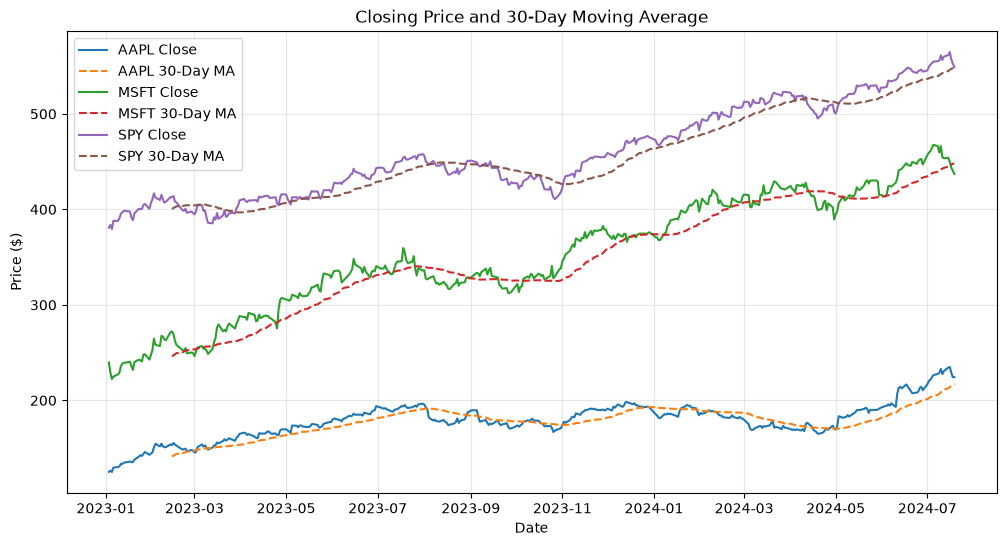

In [3]:
def plot_close_with_ma(stock_data, window=30):
    fig, ax = plt.subplots(figsize=(12, 6))
    for symbol, df in stock_data.items():
        ma = df['close'].rolling(window=window).mean()
        ax.plot(df.index, df['close'], label=f'{symbol} Close')
        ax.plot(df.index, ma, linestyle='--', label=f'{symbol} {window}-Day MA')
    ax.set_title(f'Closing Price and {window}-Day Moving Average')
    ax.set_xlabel('Date'); ax.set_ylabel('Price ($)')
    ax.legend(); ax.grid(alpha=0.3)
    plt.show()

plot_close_with_ma(stock_data)

## 3. Monthly overview

Average monthly close shows the direction of the trend. Total monthly volume shows how much trading activity there was.

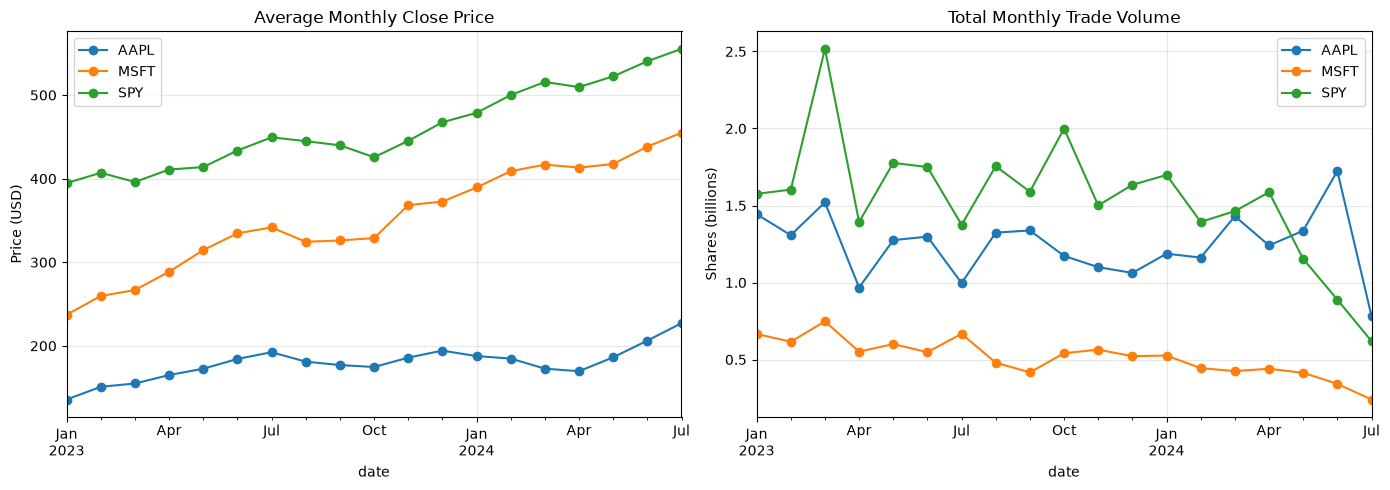

,AAPL,MSFT,SPY
date,,,
2024-03-31,172.70,416.79,515.74
2024-04-30,169.60,413.26,509.58
2024-05-31,186.29,417.54,522.42
2024-06-30,206.26,438.34,540.50
2024-07-31,227.08,454.94,555.31


In [4]:
def monthly_overview(stock_data):
    avg_close = pd.DataFrame({s: df['close'].resample('ME').mean() for s, df in stock_data.items()})
    volume = pd.DataFrame({s: df['volume'].resample('ME').sum() / 1e9 for s, df in stock_data.items()})

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    avg_close.plot(ax=axes[0], marker='o', title='Average Monthly Close Price')
    axes[0].set_ylabel('Price (USD)')
    volume.plot(ax=axes[1], marker='o', title='Total Monthly Trade Volume')
    axes[1].set_ylabel('Shares (billions)')
    for ax in axes: ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    return avg_close, volume

avg_close, monthly_volume = monthly_overview(stock_data)
avg_close.round(2).tail()

## 4. Return on investment

Daily return = (close − open) / open × 100.
Monthly return = (last close of the month − first open of the month) / first open × 100.

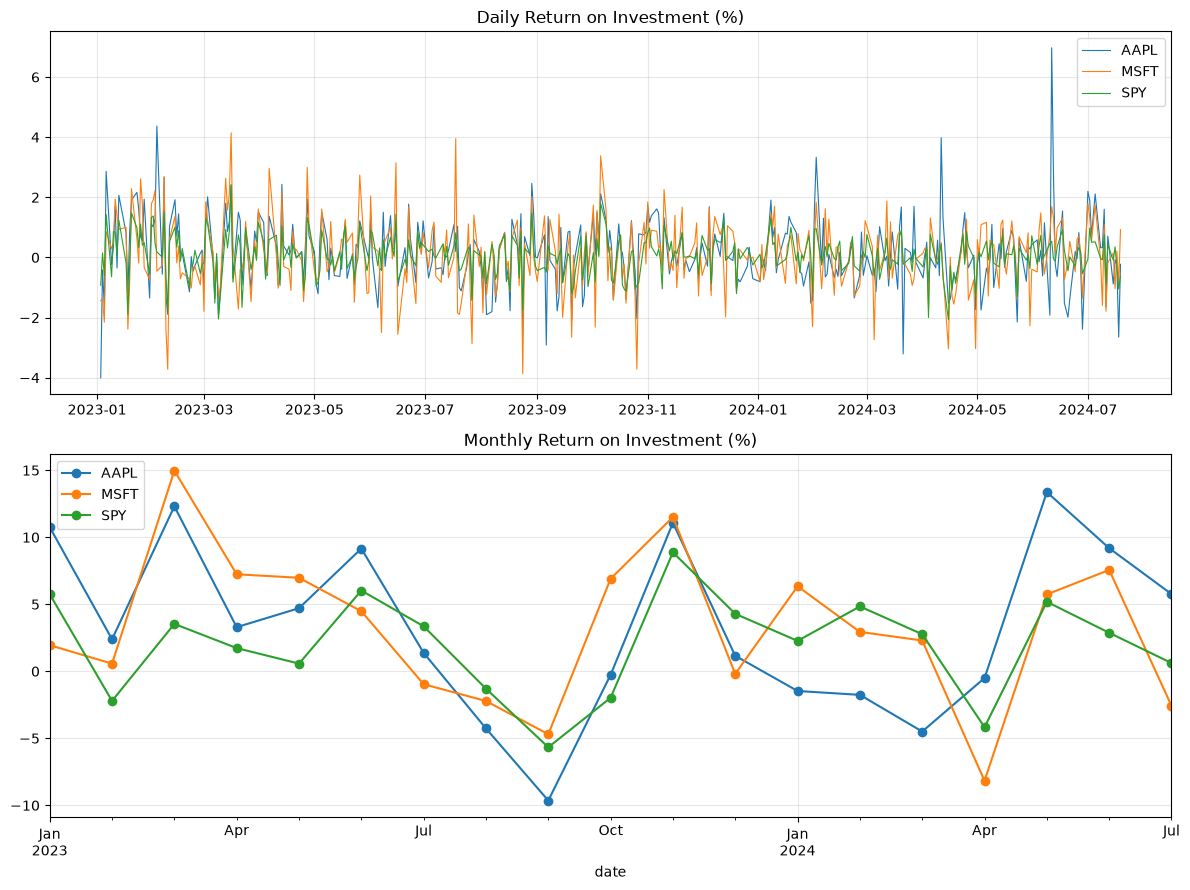

,AAPL,MSFT,SPY
date,,,
2023-01-31,10.75,1.95,5.75
2023-02-28,2.39,0.57,-2.21
2023-03-31,12.31,14.97,3.54
2023-04-30,3.29,7.24,1.73
2023-05-31,4.71,6.98,0.57
2023-06-30,9.16,4.48,6.03
2023-07-31,1.38,-0.96,3.36
2023-08-31,-4.26,-2.22,-1.30
2023-09-30,-9.64,-4.70,-5.67


In [5]:
def daily_returns(stock_data):
    return {s: (df['close'] - df['open']) / df['open'] * 100 for s, df in stock_data.items()}


def monthly_returns(stock_data):
    out = {}
    for s, df in stock_data.items():
        first_open = df['open'].resample('ME').first()
        last_close = df['close'].resample('ME').last()
        out[s] = (last_close - first_open) / first_open * 100
    return pd.DataFrame(out)


daily_ret = daily_returns(stock_data)
monthly_ret = monthly_returns(stock_data)

fig, axes = plt.subplots(2, 1, figsize=(12, 9))
for s, r in daily_ret.items():
    axes[0].plot(r.index, r, label=s, linewidth=0.8)
axes[0].set_title('Daily Return on Investment (%)'); axes[0].legend(); axes[0].grid(alpha=0.3)
monthly_ret.plot(ax=axes[1], marker='o', title='Monthly Return on Investment (%)')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

monthly_ret.round(2)

## 5. Risk analysis

**Beta** measures how much a stock moves relative to the market. Beta = cov(stock, SPY) / var(SPY). Above 1 means more volatile than the market.

**Rolling volatility** is the 30-day standard deviation of daily returns, annualized by multiplying by √252 (trading days in a year).

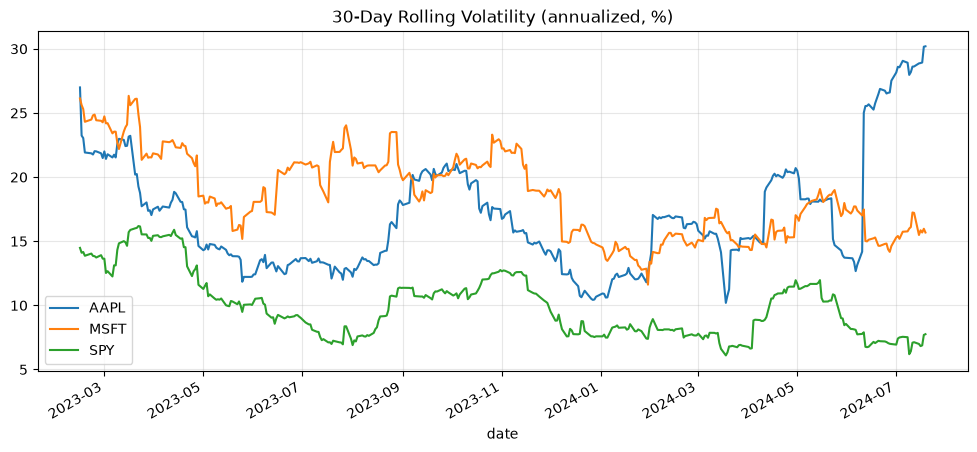

,Stock,Beta,Volatility
0,AAPL,1.156,More Volatile
1,MSFT,1.337,More Volatile
2,SPY,1.000,Similar to Market


In [6]:
def beta_table(daily_ret, market='SPY'):
    rows = []
    for s, r in daily_ret.items():
        aligned = pd.concat([r, daily_ret[market]], axis=1, join='inner').dropna()
        cov = np.cov(aligned.iloc[:, 0], aligned.iloc[:, 1])[0, 1]
        var = np.var(aligned.iloc[:, 1], ddof=1)   # same ddof as np.cov, so SPY vs itself = 1
        beta = cov / var
        if s == market:
            label = 'Similar to Market'
        else:
            label = 'More Volatile' if beta > 1 else 'Less Volatile'
        rows.append({'Stock': s, 'Beta': round(beta, 3), 'Volatility': label})
    return pd.DataFrame(rows)


def rolling_volatility(daily_ret, window=30):
    return pd.DataFrame({s: r.rolling(window).std() * np.sqrt(252) for s, r in daily_ret.items()})


betas = beta_table(daily_ret)
vol = rolling_volatility(daily_ret)

vol.plot(figsize=(12, 5), title='30-Day Rolling Volatility (annualized, %)')
plt.grid(alpha=0.3); plt.show()

betas

## 6. Frequency trends

For each month, find the highest and lowest price and the weekday it happened on. Then count which weekday shows up most often.

In [7]:
def monthly_extremes(df):
    high = df['high'].resample('ME').agg(['max', 'idxmax'])
    low = df['low'].resample('ME').agg(['min', 'idxmin'])

    high = high.rename(columns={'max': 'Highest Price of the Month', 'idxmax': 'Date'})
    high['Month'] = high['Date'].dt.month_name()
    high['Day of Week'] = high['Date'].dt.day_name()

    low = low.rename(columns={'min': 'Lowest Price of the Month', 'idxmin': 'Date'})
    low['Month'] = low['Date'].dt.month_name()
    low['Day of Week'] = low['Date'].dt.day_name()
    return high.reset_index(drop=True), low.reset_index(drop=True)


def frequency_summary(stock_data):
    for s, df in stock_data.items():
        high, low = monthly_extremes(df)
        top = high.loc[high['Highest Price of the Month'].idxmax()]
        bottom = low.loc[low['Lowest Price of the Month'].idxmin()]
        print(f'{s}')
        print(f'  Highest single high: {top["Month"]} ({top["Highest Price of the Month"]:.2f})')
        print(f'  Most frequent day for monthly highs: {high["Day of Week"].mode()[0]}')
        print(f'  Lowest single low:   {bottom["Month"]} ({bottom["Lowest Price of the Month"]:.2f})')
        print(f'  Most frequent day for monthly lows:  {low["Day of Week"].mode()[0]}')
        print()

frequency_summary(stock_data)

aapl_high, aapl_low = monthly_extremes(stock_data['AAPL'])
aapl_high

AAPL
  Highest single high: July (237.23)
  Most frequent day for monthly highs: Friday
  Lowest single low:   January (124.17)
  Most frequent day for monthly lows:  Thursday

MSFT
  Highest single high: July (468.35)
  Most frequent day for monthly highs: Friday
  Lowest single low:   January (219.35)
  Most frequent day for monthly lows:  Wednesday

SPY
  Highest single high: July (565.16)
  Most frequent day for monthly highs: Friday
  Lowest single low:   January (377.83)
  Most frequent day for monthly lows:  Friday



,Highest Price of the Month,Date,Month,Day of Week
0,147.23,2023-01-27,January,Friday
1,157.38,2023-02-03,February,Friday
2,165.00,2023-03-31,March,Friday
3,169.85,2023-04-28,April,Friday
4,179.35,2023-05-31,May,Wednesday
5,194.48,2023-06-30,June,Friday
6,198.23,2023-07-19,July,Wednesday
7,196.73,2023-08-01,August,Tuesday
8,189.98,2023-09-05,September,Tuesday
9,182.34,2023-10-12,October,Thursday


## Summary

- AAPL and MSFT both had a beta above 1 over this period, so they moved more than the market.
- Rolling volatility shows AAPL consistently riskier than SPY, with a sharp spike in mid-2024.
- AAPL monthly highs most often landed on Fridays; lows most often on Thursdays.
- Prices rose for all three. Trade volume fell for MSFT and SPY, while AAPL volume stayed roughly flat.

These are descriptive results for a 19-month window, not a trading strategy.